# 01 — Mushroom: clean en explore

We onderzoeken de **Secondary Mushroom** dataset en maken ze bruikbaar voor de volgende stap: eetbaar of giftig/onbekende eetbaarheid voorspellen. In dit notebook bouwen we nog geen voorspellend model.

**Wie werkte mee?**

- Student(en): vul hier jullie namen in en vermeld welke delen jullie zelf hebben uitgewerkt of gecontroleerd.
- AI-hulp: Codex hielp bij de structuur, code, Nederlandse uitleg en controle op verzoek van de student. Controleer de keuzes zelf en vermeld jullie eigen bijdragen eerlijk.

**Hoe lezen we dit notebook?** Eerst staat er per sectie wat we gaan doen en waarom. Daarna volgt de code, met Nederlandse commentaar. Onder het resultaat leggen we uit wat het betekent.

De opdracht beoordeelt vooral of we onze keuzes kunnen uitleggen en of we controleren wat cleaning met de data doet. Daarom maken we onderscheid tussen een controle, een experiment en een stap die we uiteindelijk echt behouden.

## 1. Welke leerstof gebruiken we?

| Leerstof in CloudAI | Wat we hier toepassen |
| --- | --- |
| `1.1 - Data Science recap.pptx`, dia 3–8 | Gemiddelde/mediaan, histogrammen, boxplots, IQR, variation en covariation, correlatie. |
| `5 - Data augmentation.pptx`, dia 7–10 en 15–22 | Scrub en Explore afwisselen, juiste types en tidy data. |
| Dezelfde PowerPoint, dia 23–37 | Outliers, nominale/ordinale categorieën, one-hot encoding en ontbrekende waarden. |
| Dezelfde PowerPoint, dia 40 en 43–45 | Bias, testinformatie apart houden en alleen schalen als het nodig is. |
| `Exercises_solved/5 data augmentation/1 - Tidy data.ipynb` | Consistente kolomnamen en uitleg bij cleaningkeuzes. |
| `2 - Outlier detection in forest.ipynb` in die map | Gevolgen van verwijderen en clipping vergelijken, ook per klasse. |
| `3 - Diamonds.ipynb` en `4 - MPG.ipynb` in die map | `CategoricalDtype`, ordinaal tegenover nominaal, `pd.get_dummies()`. |
| `8 - Titanic missing data.ipynb` in die map | Niet elke lege waarde invullen en opletten voor kunstmatige pieken. |
| `1.4 - Setting up your working environment.pptx`, dia 19–23 | Alles opnieuw kunnen uitvoeren vanuit een verse kernel. |

De volledige opdracht staat in [project assignment.md](../Discussion%20topics/project%20assignment.md). Het notebook `02_data_preparation.ipynb` herhaalt straks alleen de behouden cleaningstappen, zonder grafieken.

## 2. Libraries en werkomgeving

We gebruiken Pandas voor tabellen, NumPy voor ontbrekende waarden, en Matplotlib/Seaborn voor de grafieken. Dat zijn de libraries uit de lessen. SciPy gebruiken we alleen voor de chi-kwadraattoets die bij categorische data besproken wordt.

Kies in VS Code een Python-kernel met deze libraries. In deze projectmap heeft `.venv-1` ze al. Als ze in jouw eigen omgeving ontbreken, installeer daar `pandas numpy matplotlib seaborn scipy ipykernel`. Installeer niet telkens opnieuw wanneer je dit notebook uitvoert.

`Path` helpt alleen om het bestand te vinden. `display()` toont een tabel leesbaar in een notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import chi2_contingency
from pandas.api.types import CategoricalDtype
from pathlib import Path
from IPython.display import display

# We maken de tabellen en grafieken leesbaar.
pd.set_option('display.max_columns', 25)
pd.set_option('display.max_rows', 30)
sns.set_theme(style='whitegrid')

# Deze versies helpen om de uitvoering later te kunnen herhalen.
print('Pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Seaborn:', sns.__version__)
print('SciPy:', scipy.__version__)

ModuleNotFoundError: No module named 'seaborn'

## 3. Data inladen en de bron begrijpen

De opdracht vraagt **secondary_data.csv**. `primary_data.csv` bevat de beschrijvingen van de 173 soorten waarop de simulatie gebaseerd is. We voegen die bestanden niet bij elkaar: ze beschrijven verschillende soorten rijen.

Volgens `secondary_data_meta.txt` bevat de secondary dataset 61.069 hypothetische paddenstoelen, gemaakt vanuit 173 soorten. Er zijn 20 kenmerken en één doelkolom. Eén rij is één gesimuleerde paddenstoel, niet één nieuwe soort.

De doelkolom `class` heeft twee codes:

- `e`: volgens de bron eetbaar.
- `p`: giftig **of** onbekende eetbaarheid en daarom niet aanbevolen. We noemen dit verder kort 'giftig/onbekend'.

De simulatie heeft evenveel voorbeelden per soort gemaakt. Verhoudingen in dit bestand beschrijven daardoor de simulatie, niet hoe vaak soorten in de natuur voorkomen.

In [ ]:
# We zoeken de CSV vanuit de projectmap of vanuit de map van dit notebook.
# Zo hoef je geen pad met de naam van jouw computer in de code te zetten.
werkmap = Path.cwd()
if (werkmap / 'MushroomDataset' / 'MushroomDataset' / 'secondary_data.csv').exists():
    mushroom_map = werkmap / 'MushroomDataset'
else:
    mushroom_map = werkmap

data_pad = mushroom_map / 'MushroomDataset' / 'secondary_data.csv'
if not data_pad.exists():
    raise FileNotFoundError('Open dit notebook vanuit CloudAI of vanuit CloudAI/MushroomDataset.')

# In dit bestand worden de kolommen gescheiden door puntkomma's.
df_raw = pd.read_csv(data_pad, sep=';')
print(f'Aantal rijen: {df_raw.shape[0]:,}')
print(f'Aantal kolommen: {df_raw.shape[1]}')
display(df_raw.head())

Aantal rijen: 61,069
Aantal kolommen: 21


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


**Wat leren we?** De bron bevat 61.069 rijen en 21 kolommen. In de eerste rijen zien we getallen, lettercodes en lege waarden. De data staat al in de aangeleerde tidy-vorm: één variabele per kolom, één observatie per rij en één waarde per cel. We hoeven dus geen `melt()` te doen zoals in de tidy-dataoefening.

## 4. Kolomnamen en datatypes

We vervangen streepjes in kolomnamen door underscores. `cap-diameter` wordt bijvoorbeeld `cap_diameter`. De bron blijft bewaard in `df_raw`, zodat we later kunnen vergelijken.

We onderscheiden de doelkolom, de drie echte metingen en de 17 categorische invoerkolommen. We maken alleen lege tekst en een eventuele `?` onbekend. Een code zoals `f` verwijderen we niet: die heeft vaak een echte betekenis.

In [ ]:
# We bewaren de originele data en werken verder met een kopie.
df = df_raw.copy()

# Zoals in de tidy-dataoefening gebruiken we consistente kolomnamen.
df.columns = df.columns.str.strip().str.lower().str.replace('-', '_', regex=False)

# Dit zijn de drie echte metingen. De breedte staat in mm, de andere twee in cm.
numerieke_kolommen = ['cap_diameter', 'stem_height', 'stem_width']
categorische_kolommen = [kolom for kolom in df.columns
                        if kolom not in numerieke_kolommen + ['class']]

# We verwijderen alleen extra spaties, niet de betekenisvolle lettercodes.
for kolom in categorische_kolommen + ['class']:
    df[kolom] = df[kolom].str.strip()
    df[kolom] = df[kolom].replace({'': np.nan, '?': np.nan})

display(pd.DataFrame({'originele_naam': df_raw.columns, 'nieuwe_naam': df.columns}))

,originele_naam,nieuwe_naam
0,class,class
1,cap-diameter,cap_diameter
2,cap-shape,cap_shape
3,cap-surface,cap_surface
4,cap-color,cap_color
5,does-bruise-or-bleed,does_bruise_or_bleed
6,gill-attachment,gill_attachment
7,gill-spacing,gill_spacing
8,gill-color,gill_color
9,stem-height,stem_height


In [ ]:
# info() toont de datatypes en hoeveel waarden niet leeg zijn.
df.info()

# nunique() helpt om mogelijke categorische kolommen te herkennen.
display(df.nunique().rename('aantal_verschillende_waarden').to_frame())

<class 'pandas.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  str    
 1   cap_diameter          61069 non-null  float64
 2   cap_shape             61069 non-null  str    
 3   cap_surface           46949 non-null  str    
 4   cap_color             61069 non-null  str    
 5   does_bruise_or_bleed  61069 non-null  str    
 6   gill_attachment       51185 non-null  str    
 7   gill_spacing          36006 non-null  str    
 8   gill_color            61069 non-null  str    
 9   stem_height           61069 non-null  float64
 10  stem_width            61069 non-null  float64
 11  stem_root             9531 non-null   str    
 12  stem_surface          22945 non-null  str    
 13  stem_color            61069 non-null  str    
 14  veil_type             3177 non-null   str    
 15  veil_color            7413 non

,aantal_verschillende_waarden
class,2
cap_diameter,2571
cap_shape,7
cap_surface,11
cap_color,12
does_bruise_or_bleed,2
gill_attachment,7
gill_spacing,3
gill_color,12
stem_height,2226


## 5. Wat betekenen de kolommen?

Deze uitleg komt uit het lokale metadata-bestand. Lettercodes houden we in de data; deze tabel helpt om de grafieken te lezen. De betekenis van eenzelfde letter kan per kolom verschillen.

In [ ]:
# We zetten de uitleg naast de kolommen, zodat we geen betekenis moeten raden.
kolom_uitleg = {
    'class': ('doelklasse', 'e = eetbaar; p = giftig/onbekende eetbaarheid'),
    'cap_diameter': ('numeriek', 'diameter van de hoed in cm'),
    'cap_shape': ('nominaal', 'vorm van de hoed; b = klokvormig, x = bol, f = plat'),
    'cap_surface': ('nominaal', 'oppervlak van de hoed; s = glad, t = kleverig'),
    'cap_color': ('nominaal', 'kleur van de hoed; n = bruin, w = wit, y = geel'),
    'does_bruise_or_bleed': ('nominaal/binaire categorie', 't = kneust of bloedt; f = niet'),
    'gill_attachment': ('nominaal', 'aanhechting van de lamellen; f = geen'),
    'gill_spacing': ('nominaal', 'afstand tussen lamellen; c = dicht, d = ver, f = geen'),
    'gill_color': ('nominaal', 'kleur van de lamellen; f = geen'),
    'stem_height': ('numeriek', 'hoogte van de steel in cm'),
    'stem_width': ('numeriek', 'breedte van de steel in mm'),
    'stem_root': ('nominaal', 'vorm van de steelbasis; s = gezwollen, b = bolvormig'),
    'stem_surface': ('nominaal', 'oppervlak van de steel; f = geen'),
    'stem_color': ('nominaal', 'kleur van de steel; f = geen'),
    'veil_type': ('nominaal', 'type omhulsel; p = gedeeltelijk, u = volledig'),
    'veil_color': ('nominaal', 'kleur van het omhulsel; f = geen'),
    'has_ring': ('nominaal/binaire categorie', 't = ring aanwezig; f = geen ring'),
    'ring_type': ('nominaal', 'type ring; f = geen'),
    'spore_print_color': ('nominaal', 'kleur van de sporenafdruk'),
    'habitat': ('nominaal', 'd = bos, g = gras, l = bladeren, m = weide, p = pad, h = heide, u = stedelijk, w = afval'),
    'season': ('nominaal', 's = lente, u = zomer, a = herfst, w = winter')
}
display(pd.DataFrame.from_dict(kolom_uitleg, orient='index', columns=['type', 'betekenis']))

,type,betekenis
class,doelklasse,e = eetbaar; p = giftig/onbekende eetbaarheid
cap_diameter,numeriek,diameter van de hoed in cm
cap_shape,nominaal,"vorm van de hoed; b = klokvormig, x = bol, f =..."
cap_surface,nominaal,"oppervlak van de hoed; s = glad, t = kleverig"
cap_color,nominaal,"kleur van de hoed; n = bruin, w = wit, y = geel"
does_bruise_or_bleed,nominaal/binaire categorie,t = kneust of bloedt; f = niet
gill_attachment,nominaal,aanhechting van de lamellen; f = geen
gill_spacing,nominaal,"afstand tussen lamellen; c = dicht, d = ver, f..."
gill_color,nominaal,kleur van de lamellen; f = geen
stem_height,numeriek,hoogte van de steel in cm


### 5.1. Codes vergelijken met de metadata

De metadata is niet helemaal volledig: de CSV bevat `d` in `cap_surface` en `f` in `stem_root`, zonder dat deze codes daar beschreven worden. We bewaren deze waarden. Een niet-beschreven code is niet automatisch een fout of een ontbrekende waarde.

Ook heet de kneuskolom in de CSV `does-bruise-or-bleed`, terwijl de metadata een iets kortere naam gebruikt. We volgen de echte CSV-kolom.

De lijst hieronder legt de mogelijke categorieën vast. Dat maakt de encoding in beide notebooks gelijk. Gegedocumenteerde categorieën die niet voorkomen, kunnen later een volledig lege 0/1-kolom opleveren; dat bespreken we bij de encoding.

In [ ]:
# Deze mogelijke codes komen uit secondary_data_meta.txt.
# 'd' bij cap_surface en 'f' bij stem_root staan wel in de CSV, maar niet in die uitleg.
# We bewaren ze als aparte codes. We verzinnen er geen beschrijving bij.
kleuren = ['n', 'b', 'g', 'r', 'p', 'u', 'e', 'w', 'y', 'l', 'o', 'k']
oppervlakken = ['i', 'g', 'y', 's', 'h', 'l', 'k', 't', 'w', 'e']
mogelijke_codes = {
    'cap_shape': ['b', 'c', 'x', 'f', 's', 'p', 'o'],
    'cap_surface': oppervlakken + ['d'],
    'cap_color': kleuren,
    'does_bruise_or_bleed': ['t', 'f'],
    'gill_attachment': ['a', 'x', 'd', 'e', 's', 'p', 'f'],
    'gill_spacing': ['c', 'd', 'f'],
    'gill_color': kleuren + ['f'],
    'stem_root': ['b', 's', 'c', 'u', 'e', 'z', 'r', 'f'],
    'stem_surface': oppervlakken + ['f'],
    'stem_color': kleuren + ['f'],
    'veil_type': ['p', 'u'],
    'veil_color': kleuren + ['f'],
    'has_ring': ['t', 'f'],
    'ring_type': ['c', 'e', 'r', 'g', 'l', 'p', 's', 'z', 'y', 'm', 'f'],
    'spore_print_color': kleuren,
    'habitat': ['g', 'l', 'm', 'p', 'h', 'u', 'w', 'd'],
    'season': ['s', 'u', 'a', 'w']
}

# We controleren de waarden VOOR we er categoricals van maken.
# Anders zou een niet-herkende code ongemerkt een ontbrekende waarde kunnen worden.
for kolom, codes in mogelijke_codes.items():
    extra_codes = set(df[kolom].dropna().unique()) - set(codes)
    if extra_codes:
        raise ValueError(f'Controleer nieuwe codes in {kolom}: {extra_codes}')

if df['class'].isna().any() or not set(df['class'].unique()).issubset({'e', 'p'}):
    raise ValueError('De doelkolom moet voor iedere rij e of p bevatten.')

print('Alle categorieën zijn gecontroleerd. De twee extra broncodes blijven behouden.')

Alle categorieën zijn gecontroleerd. De twee extra broncodes blijven behouden.


## 6. Hoe zijn de klassen verdeeld?

Met `value_counts()` tellen we de twee klassen. We tonen ook percentages, omdat we straks willen weten of cleaning één klasse sterker raakt dan de andere.

,aantal,percentage
class,,
e,27181,44.51
p,33888,55.49


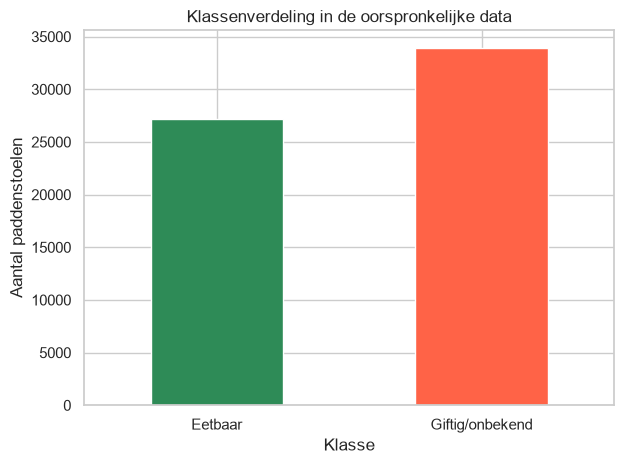

In [ ]:
# We bekijken aantallen EN percentages, zoals bij het controleren van bias.
klasse_namen = {'e': 'Eetbaar', 'p': 'Giftig/onbekend'}
klasse_voor = df['class'].value_counts().reindex(['e', 'p'])
display(pd.DataFrame({'aantal': klasse_voor,
                      'percentage': (klasse_voor / len(df) * 100).round(2)}))

klasse_voor.rename(index=klasse_namen).plot.bar(color=['seagreen', 'tomato'], rot=0)
plt.title('Klassenverdeling in de oorspronkelijke data')
plt.xlabel('Klasse')
plt.ylabel('Aantal paddenstoelen')
plt.tight_layout()
plt.show()

**Conclusie:** er zijn 27.181 eetbare en 33.888 giftige/onbekende voorbeelden. Dat is ongeveer 44,5% tegenover 55,5%. De klassen zijn dus niet extreem onevenwichtig. We hoeven voor deze cleaning geen voorbeelden bij te maken of een klasse weg te gooien om precies 50/50 te krijgen.

## 7. Ontbrekende waarden onderzoeken

Zoals in de Titanic-oefening tellen we eerst de lege waarden. We kiezen nog geen oplossing voordat we weten hoeveel informatie ontbreekt.

Een lege cel betekent dat deze eigenschap niet ingevuld is. De code `f` kan in verschillende kenmerken 'geen' betekenen. We mogen die code dus niet zomaar gelijkstellen aan een lege cel.

,aantal_ontbrekend,percentage_ontbrekend
veil_type,57892,94.80
spore_print_color,54715,89.60
veil_color,53656,87.86
stem_root,51538,84.39
stem_surface,38124,62.43
gill_spacing,25063,41.04
cap_surface,14120,23.12
gill_attachment,9884,16.18
ring_type,2471,4.05
cap_color,0,0.00


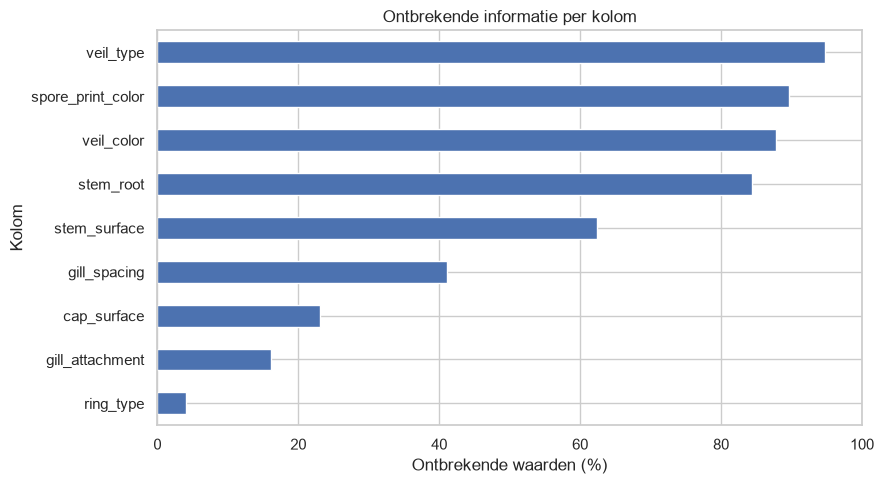

Rijen die overblijven bij dropna() op alle kolommen: 0


In [ ]:
# isna() geeft True waar een waarde ontbreekt. sum() telt deze per kolom.
missing_voor = pd.DataFrame({
    'aantal_ontbrekend': df.isna().sum(),
    'percentage_ontbrekend': (df.isna().mean() * 100).round(2)
}).sort_values('percentage_ontbrekend', ascending=False)
display(missing_voor)

missing_voor.loc[missing_voor['aantal_ontbrekend'] > 0,
                  'percentage_ontbrekend'].sort_values().plot.barh(figsize=(9, 5))
plt.title('Ontbrekende informatie per kolom')
plt.xlabel('Ontbrekende waarden (%)')
plt.ylabel('Kolom')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# Dit is alleen een experiment. We overschrijven df niet.
print('Rijen die overblijven bij dropna() op alle kolommen:', len(df.dropna()))

**Conclusie:** `dropna()` zou nul rijen overhouden. De drie metingen en de doelklasse zijn wel volledig ingevuld. De ontbrekende informatie zit in categorische kenmerken. Vooral `veil_type`, `spore_print_color`, `veil_color` en `stem_root` missen veel gegevens.

### 7.1. Zouden we de sterk onvolledige kolommen verwijderen?

In de Titanic-oefening worden bijna lege kolommen overwogen om te verwijderen. We bekijken hier als experiment de kolommen met meer dan 80% ontbrekende waarden. **80% is een gekozen grens voor deze vergelijking, geen vaste regel uit de cursus.**

We tellen hoeveel bekende waarden we daardoor verliezen. We bekijken ook of 'bekend of onbekend' samenhangt met de klasse. Zo begrijpen we wat we zouden weggooien.

In [ ]:
# Alleen onderzoeken: deze kolommen worden hier niet verwijderd.
sterk_onvolledig = missing_voor.index[missing_voor['percentage_ontbrekend'] > 80].tolist()
display(pd.DataFrame({
    'bekende_waarden_die_we_zouden_verliezen': df[sterk_onvolledig].notna().sum(),
    'aantal_verschillende_bekende_codes': df[sterk_onvolledig].nunique()
}))

for kolom in sterk_onvolledig:
    print('\nKolom:', kolom)
    bekend_onbekend = df[kolom].notna().map({True: 'bekend', False: 'onbekend'})
    display(pd.crosstab(bekend_onbekend, df['class'], normalize='index').mul(100).round(2))

,bekende_waarden_die_we_zouden_verliezen,aantal_verschillende_bekende_codes
veil_type,3177,1
spore_print_color,6354,7
veil_color,7413,6
stem_root,9531,5



Kolom: veil_type


class,e,p
veil_type,,
bekend,33.33,66.67
onbekend,45.12,54.88



Kolom: spore_print_color


class,e,p
spore_print_color,,
bekend,27.78,72.22
onbekend,46.45,53.55



Kolom: veil_color


class,e,p
veil_color,,
bekend,42.86,57.14
onbekend,44.74,55.26



Kolom: stem_root


class,e,p
stem_root,,
bekend,37.04,62.96
onbekend,45.89,54.11


**Keuze:** we behouden deze kolommen voorlopig. We kunnen de bekende categorieën bewaren en 'onbekend' apart aanduiden zonder rijen te verliezen. We claimen niet dat iedere kolom daardoor automatisch een goede predictor is: dat moet later met validatie blijken.

`veil_type` bevat maar één **bekende** code, maar ook veel lege waarden. De kolom is dus niet volledig constant. Alles met `u` invullen zou het verschil tussen bekend en onbekend uitwissen.

Het patroon van ontbrekende waarden kan ook iets zeggen over hoe de simulatie gemaakt werd. Een verband daarmee is geen bewijs dat dezelfde informatie bij echte nieuwe paddenstoelen even bruikbaar is.

### 7.2. Experiment: invullen met de modus

De modus is de meest voorkomende waarde. In de Titanic-oefening zien we dat invullen met één waarde een kunstmatige piek kan maken. We testen dat hier alleen op een kopie van `cap_surface`.

Dit is een beschrijvend experiment, geen gekozen voorbereiding. We gebruiken het resultaat niet voor het exportbestand.

,origineel_met_onbekend,experiment_met_modus
cap_surface,,
d,4432,4432
e,2584,2584
g,4724,4724
h,4974,4974
i,2225,2225
k,2303,2303
l,1412,1412
onbekend,14120,0
s,7608,7608


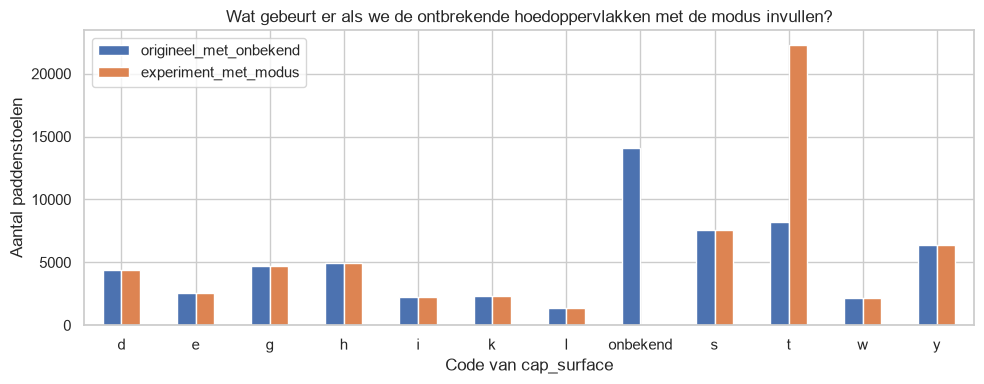

De modus is t. We zouden 14,120 waarden gokken.


In [ ]:
# We vergelijken de gemeten codes met een kopie waarin alles met de modus is ingevuld.
modus = df['cap_surface'].mode().iloc[0]
oppervlak_met_modus = df['cap_surface'].fillna(modus)
modus_vergelijking = pd.DataFrame({
    'origineel_met_onbekend': df['cap_surface'].fillna('onbekend').value_counts(),
    'experiment_met_modus': oppervlak_met_modus.value_counts()
}).fillna(0).astype(int)
display(modus_vergelijking)

modus_vergelijking.plot.bar(figsize=(10, 4), rot=0)
plt.title('Wat gebeurt er als we de ontbrekende hoedoppervlakken met de modus invullen?')
plt.xlabel('Code van cap_surface')
plt.ylabel('Aantal paddenstoelen')
plt.tight_layout()
plt.show()
print(f'De modus is {modus}. We zouden {df["cap_surface"].isna().sum():,} waarden gokken.')

**Conclusie:** de modus `t` zou 14.120 extra voorbeelden krijgen, terwijl dat oppervlak niet gemeten is. Daarom vullen we ontbrekende categorische kenmerken straks met het label `onbekend`. Het aantal lege cellen verdwijnt zo, maar de ontbrekende kennis blijft zichtbaar. Dat onderscheid is belangrijk.

## 8. Dubbele rijen en tegenstrijdige labels

We controleren volledige herhalingen én of dezelfde invoerkenmerken verschillende doelklassen hebben. Anders zouden we met `drop_duplicates()` een belangrijk probleem kunnen verbergen.

De data is gesimuleerd en afgerond; een identieke rij bewijst niet dat er een fout gemaakt is. Voor de volgende modelstap kiezen we toch voor unieke voorbeelden. Zo vermijden we dat een exact herhaald voorbeeld zowel in training als in test terechtkomt. We controleren hoeveel de klassenverdeling daardoor verandert.

In [ ]:
# duplicated() markeert herhalingen na de eerste identieke rij.
duplicaten = df.duplicated()
print('Aantal volledige herhalingen:', int(duplicaten.sum()))
display(df.loc[duplicaten, 'class'].value_counts().rename('verwijderde_herhalingen').to_frame())

# We groeperen op de invoer, zonder de doelkolom.
# dropna=False zorgt dat ook voorbeelden met ontbrekende kenmerken worden vergeleken.
invoerkolommen = numerieke_kolommen + categorische_kolommen
labels_per_invoer = df.groupby(invoerkolommen, dropna=False)['class'].nunique()
print('Aantal identieke invoercombinaties met verschillende labels:', int((labels_per_invoer > 1).sum()))

Aantal volledige herhalingen: 146


,verwijderde_herhalingen
class,
p,146


Aantal identieke invoercombinaties met verschillende labels: 0


In [ ]:
# We verwijderen alleen volledige herhalingen, inclusief dezelfde doelklasse.
# We maken geen keuze tussen verschillende labels voor dezelfde kenmerken.
df_clean = df.drop_duplicates().copy()
print(f'Rijen voor verwijderen: {len(df):,}')
print(f'Rijen na verwijderen: {len(df_clean):,}')
print(f'Verwijderde herhalingen: {len(df) - len(df_clean)}')

Rijen voor verwijderen: 61,069
Rijen na verwijderen: 60,923
Verwijderde herhalingen: 146


In [ ]:
# Dit is de voor/na-vergelijking uit de outlier-oefening, toegepast op duplicaten.
klasse_na_duplicaten = df_clean['class'].value_counts().reindex(['e', 'p'])
display(pd.DataFrame({
    'voor': klasse_voor,
    'na': klasse_na_duplicaten,
    'verlies_per_klasse_pct': ((klasse_voor - klasse_na_duplicaten) / klasse_voor * 100).round(3),
    'aandeel_voor_pct': (klasse_voor / len(df) * 100).round(3),
    'aandeel_na_pct': (klasse_na_duplicaten / len(df_clean) * 100).round(3)
}))

,voor,na,verlies_per_klasse_pct,aandeel_voor_pct,aandeel_na_pct
class,,,,,
e,27181,27181,0.000,44.509,44.615
p,33888,33742,0.431,55.491,55.385


**Conclusie:** we verwijderen 146 herhalingen, allemaal uit klasse `p`. Dat is ongeveer 0,43% van die klasse. Er zijn geen identieke invoercombinaties met tegenstrijdige labels. Er blijven 60.923 unieke rijen over. De klasseverhouding verandert weinig, maar we vermelden het effect wel.

Dit voorkomt exacte herhalingen tussen latere subsets. Het bewijst niet dat de overblijvende voorbeelden onafhankelijke soorten zijn: ze komen nog steeds uit dezelfde simulatie van 173 soorten.

## 9. Numerieke verdelingen bekijken

Een histogram toont hoe de waarden verdeeld zijn. Een boxplot toont de mediaan, Q1 en Q3 en markeert mogelijke uitschieters. Zoals in de slides: de lijn in de box is de **mediaan**, niet het gemiddelde.

We gebruiken aparte assen, omdat steelbreedte in millimeter staat en de andere metingen in centimeter. De samenvatting wordt berekend op alle unieke rijen.

,cap_diameter,stem_height,stem_width
count,60923.00,60923.00,60923.00
mean,6.74,6.60,12.18
std,5.27,3.36,10.03
min,0.38,0.00,0.00
25%,3.49,4.65,5.25
50%,5.88,5.96,10.22
75%,8.55,7.75,16.58
max,62.34,33.92,103.91


,gemiddelde,mediaan
cap_diameter,6.74,5.88
stem_height,6.60,5.96
stem_width,12.18,10.22


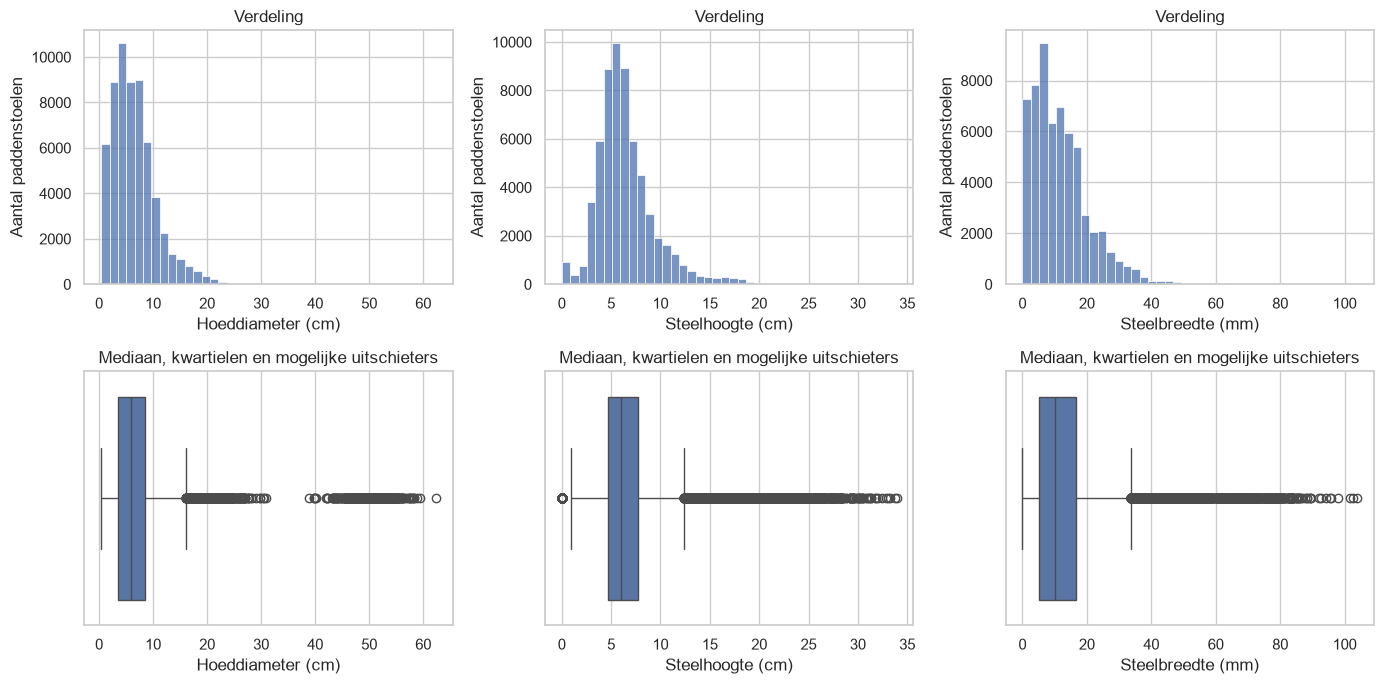

In [ ]:
# describe() toont onder andere gemiddelde, spreiding, minimum en kwartielen.
display(df_clean[numerieke_kolommen].describe().round(2))
display(pd.DataFrame({
    'gemiddelde': df_clean[numerieke_kolommen].mean(),
    'mediaan': df_clean[numerieke_kolommen].median()
}).round(2))

meetnamen = {'cap_diameter': 'Hoeddiameter (cm)',
             'stem_height': 'Steelhoogte (cm)',
             'stem_width': 'Steelbreedte (mm)'}
fig, assen = plt.subplots(2, 3, figsize=(14, 7))
for i, kolom in enumerate(numerieke_kolommen):
    sns.histplot(data=df_clean, x=kolom, bins=40, ax=assen[0, i])
    assen[0, i].set_xlabel(meetnamen[kolom])
    assen[0, i].set_ylabel('Aantal paddenstoelen')
    assen[0, i].set_title('Verdeling')
    sns.boxplot(data=df_clean, x=kolom, ax=assen[1, i])
    assen[1, i].set_xlabel(meetnamen[kolom])
    assen[1, i].set_title('Mediaan, kwartielen en mogelijke uitschieters')
plt.tight_layout()
plt.show()

**Conclusie:** de metingen hebben een lange staart naar rechts. Het gemiddelde ligt boven de mediaan. Scheefheid is volgens de slides geen fout die we automatisch moeten oplossen. De boxplots tonen grote waarden die verder onderzoek verdienen.

## 10. Outliers markeren met IQR

Q1 is de grens waaronder 25% van de waarden ligt. Q3 is de grens waaronder 75% ligt. We volgen de regel uit de slides:

- `IQR = Q3 - Q1`.
- Mogelijke outlier: kleiner dan `Q1 - 1,5 × IQR` of groter dan `Q3 + 1,5 × IQR`.

De grens markeert een statistisch extreme waarde. Ze bewijst niet dat die waarde verkeerd is. Net zoals in de forest-oefening tellen we eerst wat we zouden verliezen, ook per klasse. We gebruiken één gezamenlijke selectie; een rij met meerdere uitschieters wordt maar één keer geteld.

In [ ]:
# We bewaren voor iedere meting of de rij buiten de IQR-grenzen valt.
outlier_flags = pd.DataFrame(index=df_clean.index)
outlier_overzicht = []
for kolom in numerieke_kolommen:
    q1 = df_clean[kolom].quantile(0.25)
    q3 = df_clean[kolom].quantile(0.75)
    iqr = q3 - q1
    # We ronden alleen de berekende grens af, niet de oorspronkelijke metingen.
    # Zo wordt een theoretische grens van 0 geen heel klein positief computergetal.
    ondergrens = round(q1 - 1.5 * iqr, 6)
    bovengrens = round(q3 + 1.5 * iqr, 6)
    outlier_flags[kolom] = (df_clean[kolom] < ondergrens) | (df_clean[kolom] > bovengrens)
    outlier_overzicht.append({'kolom': kolom, 'ondergrens': ondergrens,
                             'bovengrens': bovengrens,
                             'mogelijke_outliers': int(outlier_flags[kolom].sum())})
display(pd.DataFrame(outlier_overzicht).round(2))

# any(axis=1) betekent: heeft deze rij minstens één mogelijke outlier?
heeft_outlier = outlier_flags.any(axis=1)
zonder_outliers = df_clean.loc[~heeft_outlier]
klasse_zonder_outliers = zonder_outliers['class'].value_counts().reindex(['e', 'p'], fill_value=0)
display(pd.DataFrame({
    'voor': klasse_na_duplicaten,
    'na_experiment': klasse_zonder_outliers,
    'verlies_per_klasse_pct': ((klasse_na_duplicaten - klasse_zonder_outliers)
                              / klasse_na_duplicaten * 100).round(2)
}))
print('Unieke rijen die we zouden verwijderen:', int(heeft_outlier.sum()))

,kolom,ondergrens,bovengrens,mogelijke_outliers
0,cap_diameter,-4.10,16.14,2389
1,stem_height,0.00,12.40,3159
2,stem_width,-11.74,33.58,1980


,voor,na_experiment,verlies_per_klasse_pct
class,,,
e,27181,24418,10.17
p,33742,31174,7.61


Unieke rijen die we zouden verwijderen: 5331


**Resultaat van het IQR-experiment:** we zouden 5.331 unieke rijen verliezen. Dat is 10,17% van de eetbare voorbeelden en 7,61% van de giftige/onbekende voorbeelden. De verwijdering raakt dus niet iedere klasse even sterk. Daarom onderzoeken we eerst wat die extreme metingen betekenen, zoals in de forest-oefening.

### 10.1. Zijn metingen van nul een fout?

Een hoogte of breedte van nul valt op. We bekijken de andere kenmerken van die rijen. We zoeken naar consistentie in de brondata, niet naar een reden om ieder ongewoon voorbeeld te verwijderen.

In [ ]:
# We bekijken de combinaties, zodat we weten welke kenmerken samen voorkomen.
steel_nul = df_clean.loc[(df_clean['stem_height'] == 0) | (df_clean['stem_width'] == 0)]
display(steel_nul[['stem_height', 'stem_width', 'stem_root', 'stem_surface',
                  'stem_color', 'class']].value_counts(dropna=False).rename('aantal').to_frame())

# Negatieve afmetingen zijn een andere controle dan de statistische IQR-regel.
display((df_clean[numerieke_kolommen] < 0).sum().rename('negatieve_metingen').to_frame())

,,,,,,aantal
stem_height,stem_width,stem_root,stem_surface,stem_color,class,
0.0,0.0,f,f,f,p,915


,negatieve_metingen
cap_diameter,0
stem_height,0
stem_width,0


**Keuze:** de nulmetingen gaan samen met `f` bij steeloppervlak en steelkleur, waar de metadata 'geen' vermeldt. Dat ondersteunt dat deze rijen een paddenstoel zonder steel beschrijven. We behouden de nullen; we maken er geen geschatte positieve hoogte van. Voor `stem_root = f` blijft de beschrijving in de metadata onvolledig.

Er zijn geen negatieve metingen. Voor de grote waarden hebben we geen bewijs van een meetfout. We behouden daarom de statistische outliers en leggen vast waarom.

### 10.2. Experiment: conservatief clippen

In de forest-oefening wordt ook clipping onderzocht: waarden buiten een grens worden tot die grens teruggebracht. We vergelijken dezelfde conservatieve percentielen uit het einde van die oefening: 0,5% en 99,5%.

Dit gebeurt op een aparte kopie. We vergelijken met dezelfde histogramgrenzen, zodat het verschil zichtbaar is. De percentielen hieronder horen bij dit experiment; ze worden niet gebruikt voor de uiteindelijke voorbereiding of een model.

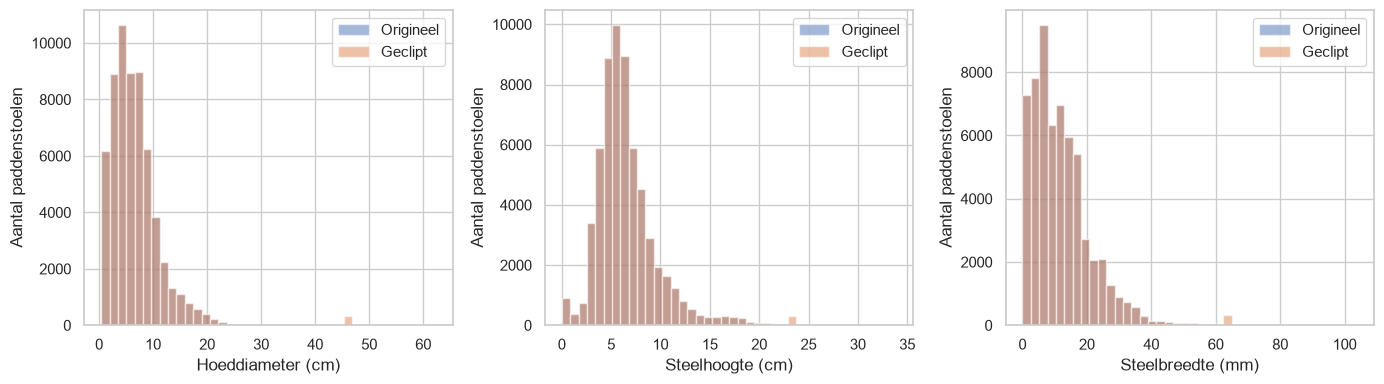

,kolom,lage_grens,hoge_grens,aantal_aangepast
0,cap_diameter,0.65,46.07,587
1,stem_height,0.00,22.98,304
2,stem_width,0.00,63.93,305


In [ ]:
# Alleen een experiment: df_clean blijft ongewijzigd.
df_geclipt = df_clean.copy()
clip_overzicht = []
fig, assen = plt.subplots(1, 3, figsize=(14, 4))
for i, kolom in enumerate(numerieke_kolommen):
    laag, hoog = df_clean[kolom].quantile([0.005, 0.995])
    df_geclipt[kolom] = df_clean[kolom].clip(lower=laag, upper=hoog)
    gewijzigd = (df_geclipt[kolom] != df_clean[kolom]).sum()
    clip_overzicht.append({'kolom': kolom, 'lage_grens': laag, 'hoge_grens': hoog,
                           'aantal_aangepast': int(gewijzigd)})
    bins = np.linspace(df_clean[kolom].min(), df_clean[kolom].max(), 41)
    assen[i].hist(df_clean[kolom], bins=bins, alpha=0.5, label='Origineel')
    assen[i].hist(df_geclipt[kolom], bins=bins, alpha=0.5, label='Geclipt')
    assen[i].set_xlabel(meetnamen[kolom])
    assen[i].set_ylabel('Aantal paddenstoelen')
    assen[i].legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame(clip_overzicht).round(2))

**Keuze:** clipping verandert echte metingen en kan waarden op een grens laten samenkomen. Een kortere staart is op zichzelf geen bewijs dat de data beter wordt. Zonder aangetoonde fouten of een latere verbetering op validatiedata behouden we de oorspronkelijke metingen. Er komt dus geen IQR-filter of clipping in notebook 02.

## 11. Logische combinaties controleren

De opdrachten vragen meer dan alleen lege cellen tellen. We controleren bijvoorbeeld of 'heeft geen ring' en het ringtype bij elkaar passen. De kruis- of contingentietabel uit de les is daarvoor bruikbaar.

In [ ]:
# Ontbrekende waarden worden voor de weergave apart getoond.
ring_tabel = pd.crosstab(df_clean['has_ring'], df_clean['ring_type'].fillna('onbekend'))
display(ring_tabel)

ring_tegenstrijdig = (df_clean['has_ring'] == 't') & (df_clean['ring_type'] == 'f')
print('Rijen met has_ring = t en ring_type = f:', int(ring_tegenstrijdig.sum()))
display(df_clean.loc[ring_tegenstrijdig, 'class'].value_counts().to_frame('aantal'))

ring_type,e,f,g,l,m,onbekend,p,r,z
has_ring,,,,,,,,,
f,0,45756,0,0,0,0,0,0,0
t,2435,2459,1240,1427,353,2471,1265,1399,2118


Rijen met has_ring = t en ring_type = f: 2459


,aantal
class,
p,2106
e,353


**Conclusie en keuze:** de bron bevat combinaties 'ring aanwezig' en 'ringtype = geen'. We weten niet welke van de twee velden verkeerd is. Daarom behouden we de bronwaarden en vermelden we de tegenstrijdigheid. We verzinnen geen ringtype en verwijderen de rijen niet automatisch. Bij later modelleren kunnen we met validatie vergelijken wat het behouden of weglaten van zo'n kenmerk doet.

## 12. Ontbrekende categorieën herkenbaar maken

Nu voeren we de gekozen behandeling uit. Een leeg categorisch kenmerk krijgt de categorie `onbekend`. We gebruiken `CategoricalDtype`, zoals in de Diamonds-oefening.

Alle invoercategorieën zijn hier **nominaal**. `season` is een seizoensnaam, geen grootte. Lente, zomer, herfst en winter kunnen we netjes op de x-as ordenen, maar we doen niet alsof hun codes getallen met een oplopende waarde zijn.

In [ ]:
# Een ontbrekende waarde wordt 'onbekend'. Dat is geen voorspelde kleur of vorm.
# De bestaande code 'f' blijft bestaan. De betekenis van die code hangt van de kolom af.
for kolom in categorische_kolommen:
    df_clean[kolom] = df_clean[kolom].fillna('onbekend')

    # Zoals in de Diamonds-oefening gebruiken we CategoricalDtype.
    # Deze categorieën hebben geen grootte of rangorde, dus ordered=False.
    categorie_type = CategoricalDtype(
        categories=mogelijke_codes[kolom] + ['onbekend'], ordered=False
    )
    df_clean[kolom] = df_clean[kolom].astype(categorie_type)

df_clean['class'] = df_clean['class'].astype(
    CategoricalDtype(categories=['e', 'p'], ordered=False)
)
print('Ontbrekende informatie is nu herkenbaar als de categorie onbekend.')

Ontbrekende informatie is nu herkenbaar als de categorie onbekend.


In [ ]:
# Deze tabel laat zien dat we onbekende informatie nog steeds kunnen terugvinden.
display(pd.DataFrame({
    'lege_cellen_na': df_clean.isna().sum(),
    'expliciet_onbekend_na': pd.Series({kolom: int((df_clean[kolom] == 'onbekend').sum())
                                      for kolom in categorische_kolommen})
}).fillna(0).astype(int))

,lege_cellen_na,expliciet_onbekend_na
cap_color,0,0
cap_diameter,0,0
cap_shape,0,0
cap_surface,0,14120
class,0,0
does_bruise_or_bleed,0,0
gill_attachment,0,9855
gill_color,0,0
gill_spacing,0,25062
habitat,0,0


## 13. Verdeling van alle categorische kenmerken

Een staafdiagram hoort bij categorieën; een histogram hoort bij metingen. We bekijken hier alle 17 categorische invoerkenmerken, in kleine groepen grafieken. De codes zijn dezelfde als in de metadata. `onbekend` blijft zichtbaar als aparte balk.

De vaste categorieën kunnen mogelijkheden bevatten die niet in de data voorkomen. Voor deze grafieken tonen we alleen categorieën met minstens één voorbeeld.

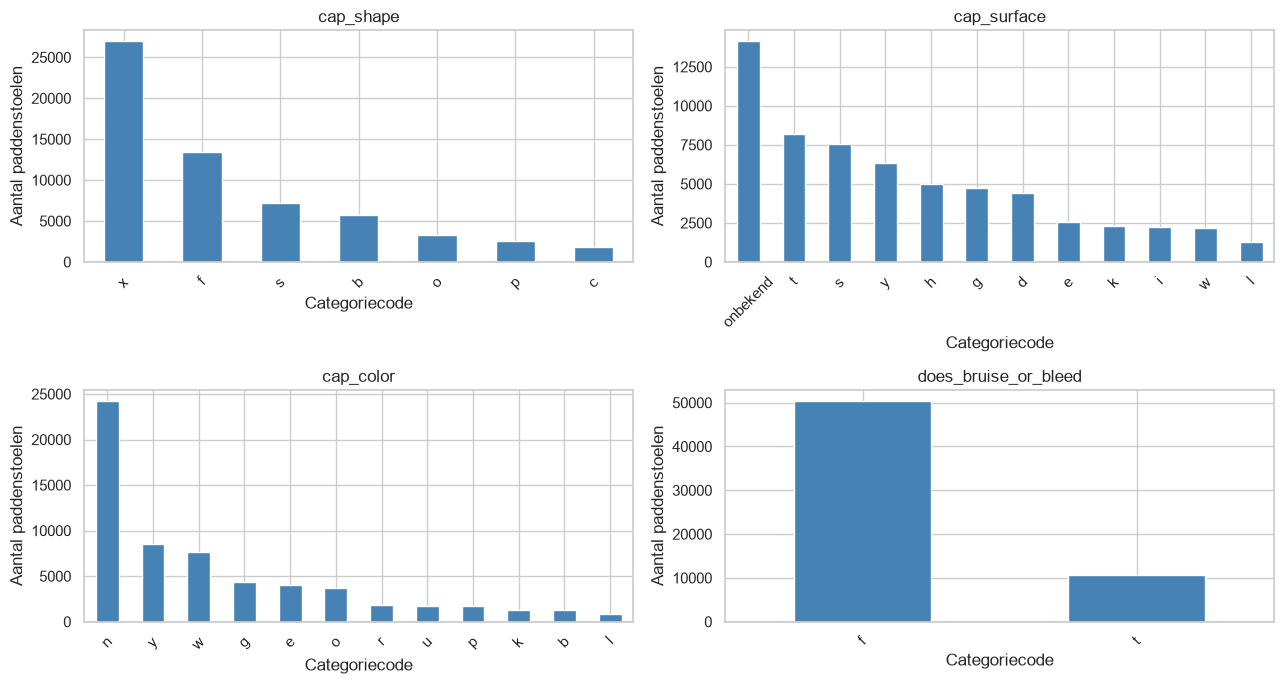

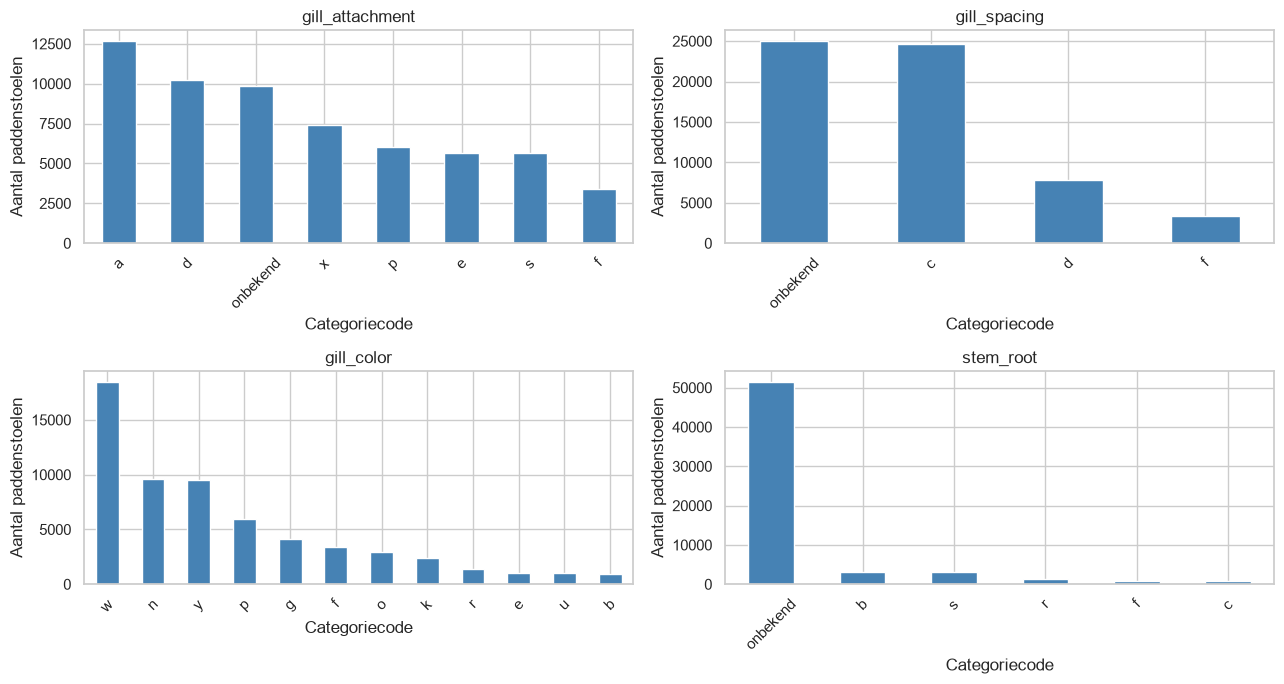

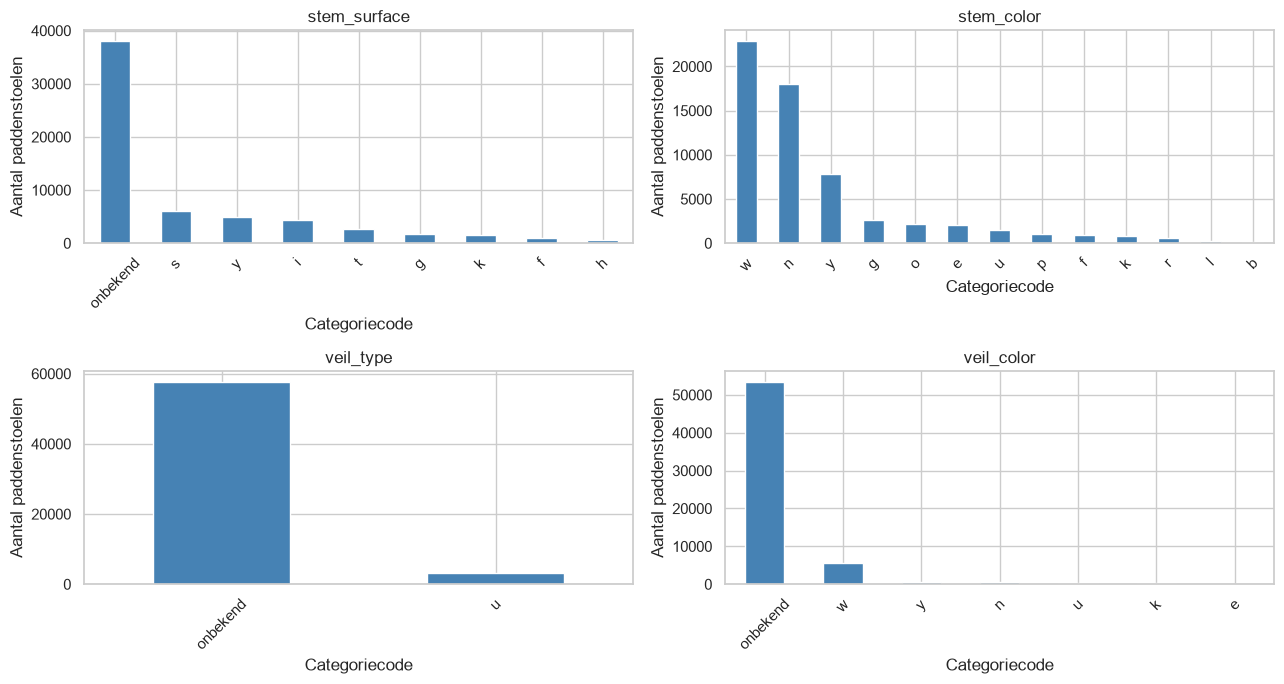

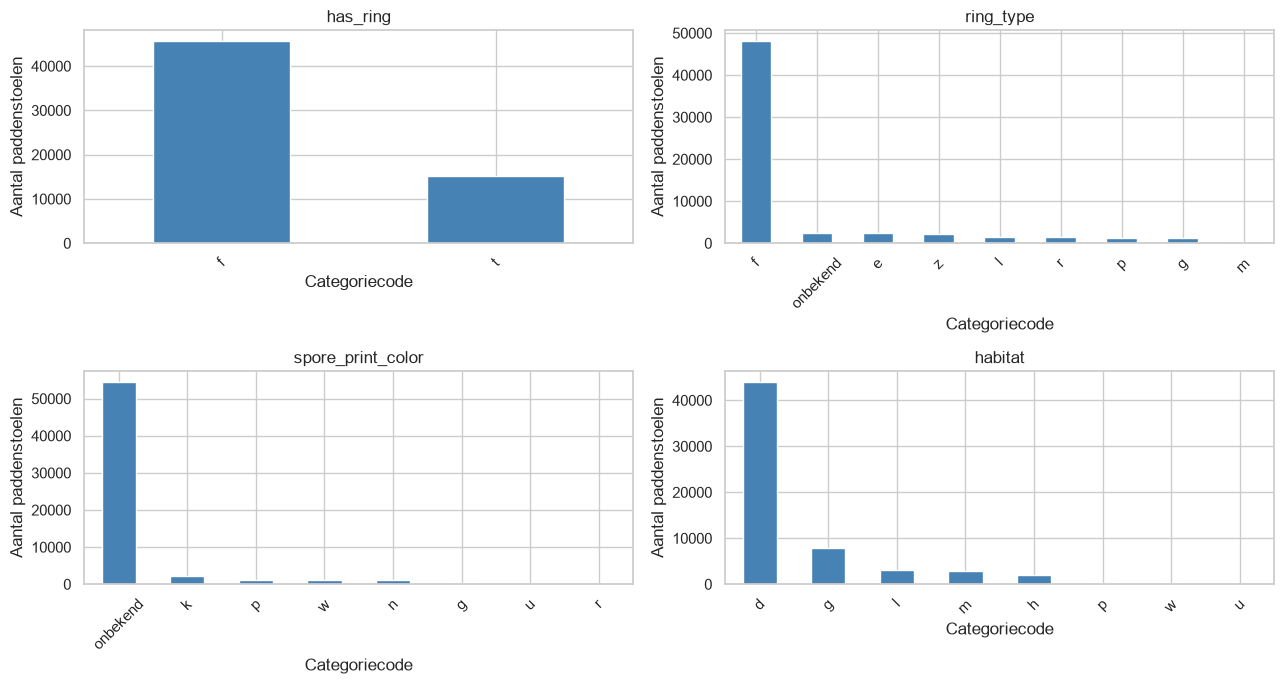

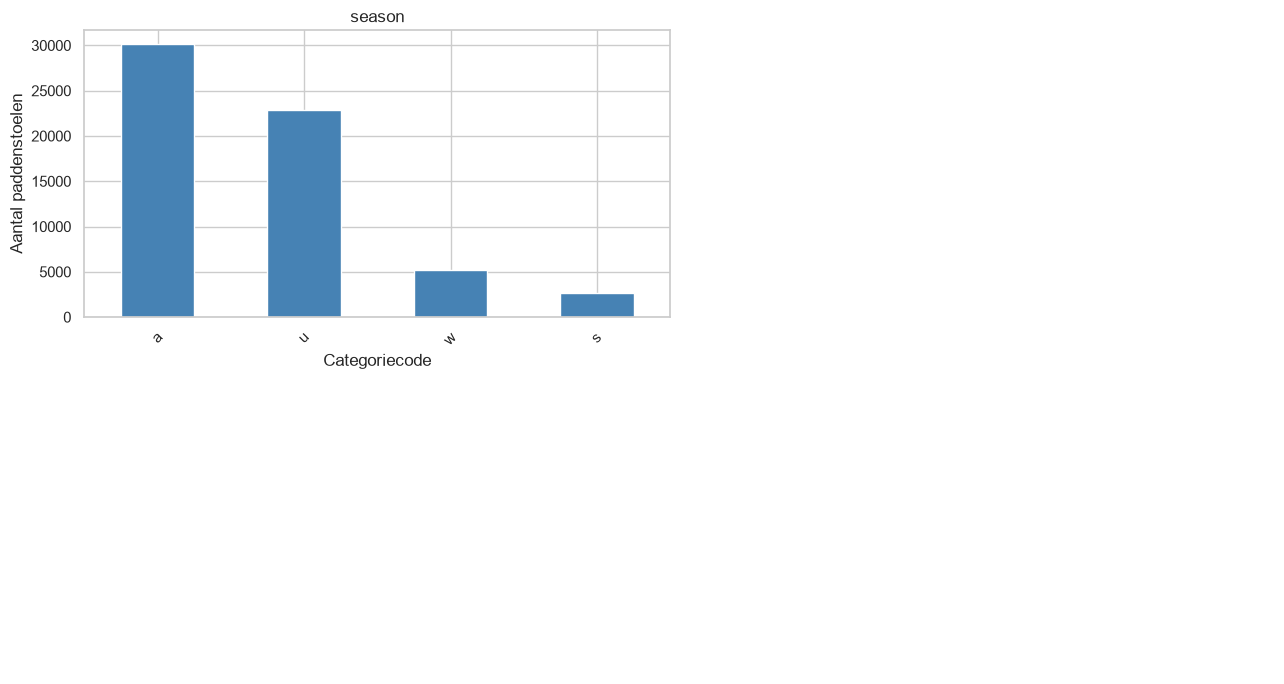

In [ ]:
# We maken groepen van maximaal vier grafieken, zodat ze leesbaar blijven.
for start in range(0, len(categorische_kolommen), 4):
    fig, assen = plt.subplots(2, 2, figsize=(13, 7))
    assen = assen.flatten()
    groep = categorische_kolommen[start:start + 4]
    for i, kolom in enumerate(groep):
        aantallen = df_clean[kolom].value_counts()
        aantallen = aantallen[aantallen > 0]
        aantallen.plot.bar(ax=assen[i], color='steelblue', rot=45)
        assen[i].set_title(kolom)
        assen[i].set_xlabel('Categoriecode')
        assen[i].set_ylabel('Aantal paddenstoelen')
    for i in range(len(groep), 4):
        assen[i].axis('off')
    plt.tight_layout()
    plt.show()

**Conclusie:** sommige kenmerken hebben veel verschillende codes, terwijl andere bijna volledig uit `onbekend` bestaan. `habitat = d` (bos) komt veel voor en herfst/zomer domineren de seizoenskolom. Dit beschrijft hoe de simulatie samengesteld is. Een zeldzame categorie is geen numerieke outlier die we met IQR moeten verwijderen.

## 14. Numerieke kenmerken vergelijken tussen de klassen

Dit is **covariation** uit de recap: we bekijken twee variabelen samen. De klasse is categorisch en een afmeting is numeriek. Daarom gebruiken we gegroepeerde boxplots en een tabel met gemiddelden en medianen.

cap_diameter              stem_height              stem_width         \
              mean median   std        mean median   std       mean median   
class                                                                        
e             7.80   6.71  6.37        7.04   6.24  3.58      14.36  12.59   
p             5.89   5.00  3.97        6.24   5.64  3.12      10.42   7.70   

              
         std  
class         
e      11.04  
p       8.75

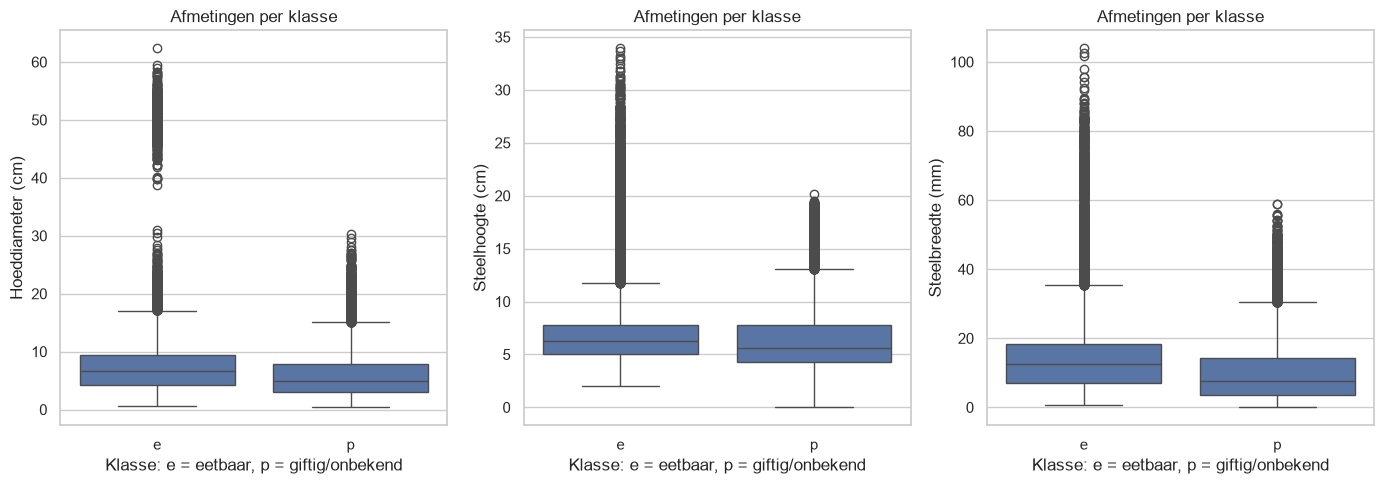

In [ ]:
display(df_clean.groupby('class', observed=True)[numerieke_kolommen]
        .agg(['mean', 'median', 'std']).round(2))

fig, assen = plt.subplots(1, 3, figsize=(14, 5))
for i, kolom in enumerate(numerieke_kolommen):
    sns.boxplot(data=df_clean, x='class', y=kolom, order=['e', 'p'], ax=assen[i])
    assen[i].set_xlabel('Klasse: e = eetbaar, p = giftig/onbekend')
    assen[i].set_ylabel(meetnamen[kolom])
    assen[i].set_title('Afmetingen per klasse')
plt.tight_layout()
plt.show()

**Conclusie:** de eetbare voorbeelden hebben hier grotere mediane afmetingen: een hoeddiameter van 6,71 tegenover 5,00 cm, een steelhoogte van 6,24 tegenover 5,64 cm en een steelbreedte van 12,59 tegenover 7,70 mm. De groepen overlappen wel sterk. Eén simpele grens in een afmeting scheidt de klassen dus niet volledig.

Dat verschil maakt de afmetingen interessant voor later modelleren. Het bewijst niet dat iedere grote paddenstoel eetbaar is. We beoordelen het midden én de spreiding, zoals in de les.

## 15. Verbanden tussen numerieke kenmerken

Voor twee metingen gebruiken we scatterplots en correlatie, zoals in de recap. De correlatie wordt op alle unieke rijen berekend. Voor de scatterplots nemen we 5.000 rijen met `random_state=42`, zodat punten niet onleesbaar over elkaar liggen. Die selectie is alleen voor de tekening; we verwijderen geen data.

Correlatie beschrijft een **lineair** verband. Een correlatie dicht bij nul sluit een gebogen verband niet uit. Correlatie bewijst ook geen oorzaak.

,cap_diameter,stem_height,stem_width
cap_diameter,1.000,0.422,0.695
stem_height,0.422,1.000,0.433
stem_width,0.695,0.433,1.000


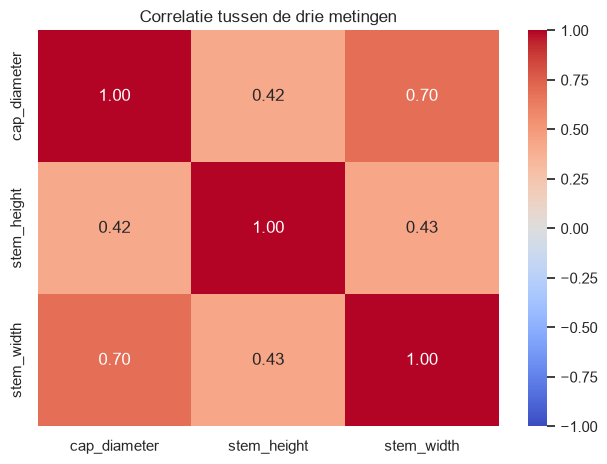

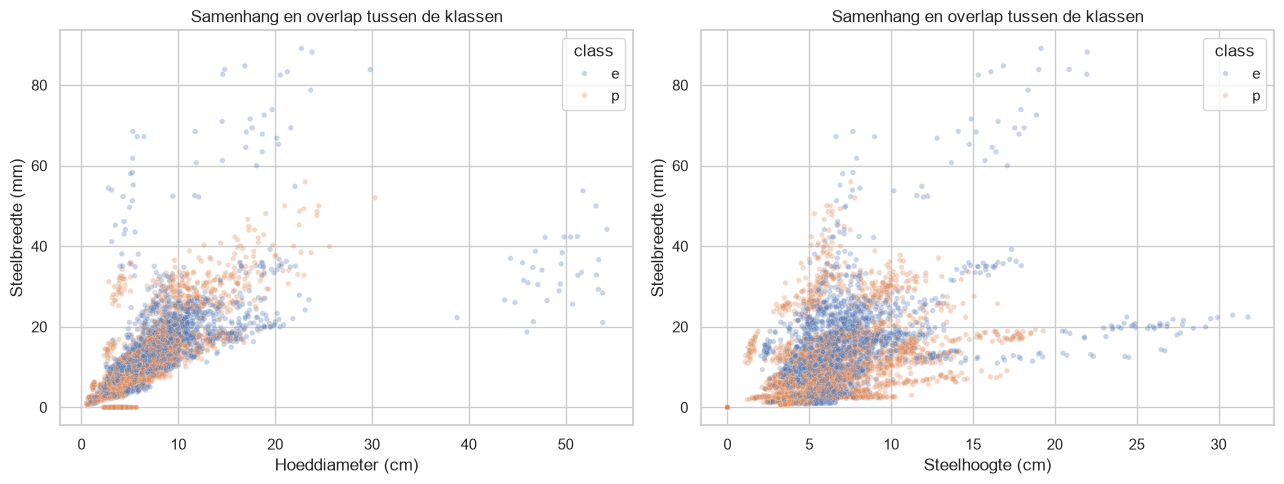

In [ ]:
# De berekening gebruikt de hele schoongemaakte dataset.
correlaties = df_clean[numerieke_kolommen].corr()
display(correlaties.round(3))
sns.heatmap(correlaties, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Correlatie tussen de drie metingen')
plt.tight_layout()
plt.show()

# Alleen de grafiek gebruikt een kleinere, herhaalbare selectie.
plot_data = df_clean.sample(n=5000, random_state=42)
fig, assen = plt.subplots(1, 2, figsize=(13, 5))
for i, x_kolom in enumerate(['cap_diameter', 'stem_height']):
    sns.scatterplot(data=plot_data, x=x_kolom, y='stem_width', hue='class',
                    hue_order=['e', 'p'], alpha=0.3, s=15, ax=assen[i])
    assen[i].set_xlabel(meetnamen[x_kolom])
    assen[i].set_ylabel(meetnamen['stem_width'])
    assen[i].set_title('Samenhang en overlap tussen de klassen')
plt.tight_layout()
plt.show()

**Conclusie:** hoeddiameter en steelbreedte hangen het sterkst samen: de correlatie is ongeveer 0,695. Grotere hoeden gaan in deze data dus vaak samen met bredere stelen. De correlaties met steelhoogte zijn ongeveer 0,42 en 0,43.

We verwijderen geen kolom alleen omdat er correlatie is: de relatie is niet perfect en een later model kan combinaties gebruiken. De puntenwolk toont bovendien overlap tussen de klassen. We berekenen geen gemiddelde van lettercodes om een extra correlatie met de klasse te verzinnen.

## 16. Categorische kenmerken vergelijken met de klasse

Nu bekijken we twee categorische variabelen samen. We gebruiken aantallen én percentages per categorie. Alleen aantallen vergelijken zou misleidend zijn wanneer bijvoorbeeld veel meer voorbeelden uit bos dan uit stedelijk gebied komen.

De seizoenen krijgen alleen voor de grafiek een leesbare volgorde. Dat is geen ordinale encoding.


Kenmerk: has_ring


class,e,p
has_ring,,
t,6001,9166
f,21180,24576


class,e,p
has_ring,,
t,39.57,60.43
f,46.29,53.71


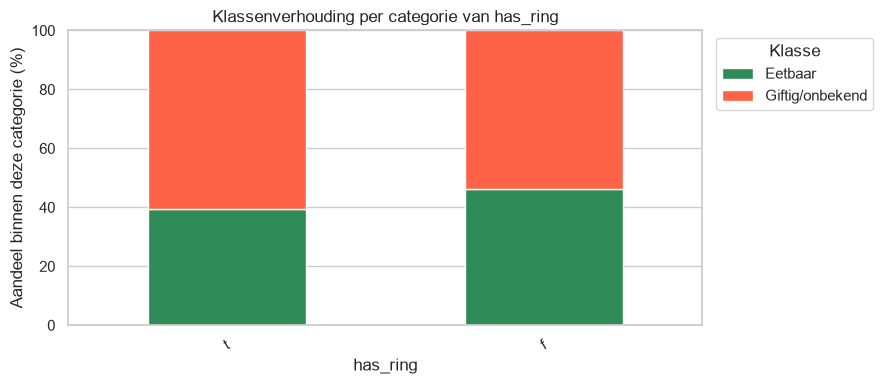


Kenmerk: does_bruise_or_bleed


class,e,p
does_bruise_or_bleed,,
t,4942,5648
f,22239,28094


class,e,p
does_bruise_or_bleed,,
t,46.67,53.33
f,44.18,55.82


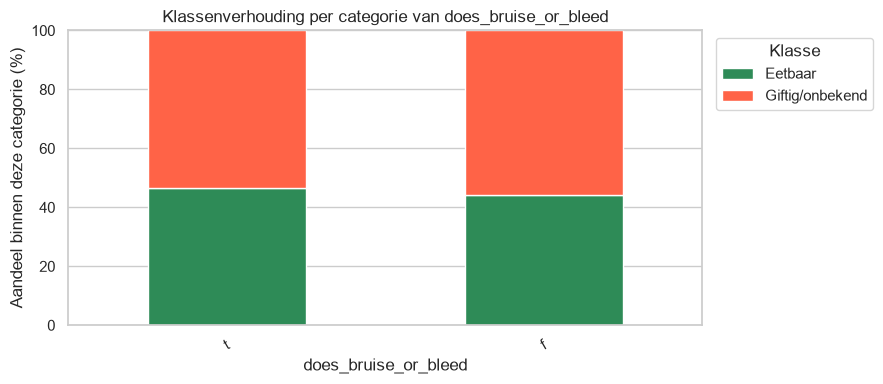


Kenmerk: habitat


class,e,p
habitat,,
g,2489,5454
l,1938,1230
m,1427,1493
p,0,360
h,696,1305
u,115,0
w,353,0
d,20163,23900


class,e,p
habitat,,
g,31.34,68.66
l,61.17,38.83
m,48.87,51.13
p,0.00,100.00
h,34.78,65.22
u,100.00,0.00
w,100.00,0.00
d,45.76,54.24


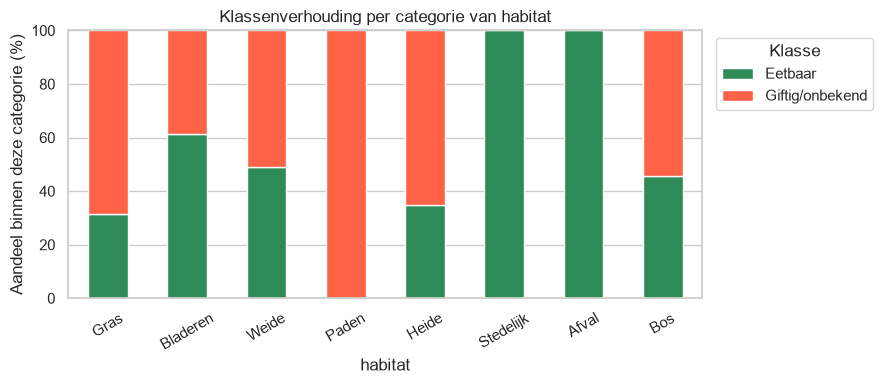


Kenmerk: season


class,e,p
season,,
s,1553,1146
u,9647,13203
a,12785,17356
w,3196,2037


class,e,p
season,,
s,57.54,42.46
u,42.22,57.78
a,42.42,57.58
w,61.07,38.93


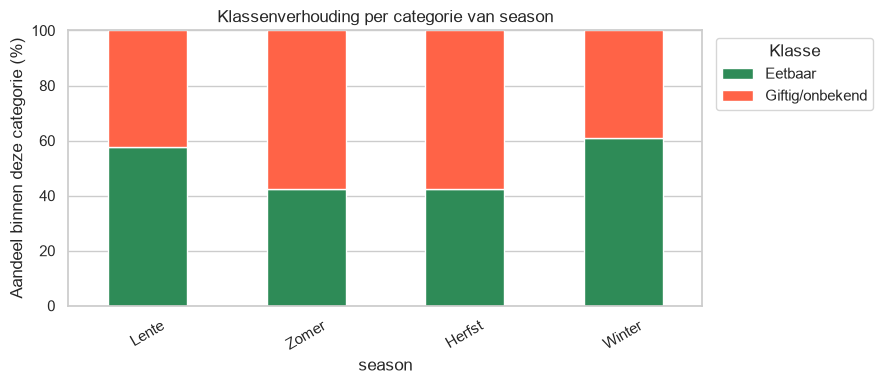

In [ ]:
# Iedere rij van de percentagetabel telt op tot 100%.
seizoen_namen = {'s': 'Lente', 'u': 'Zomer', 'a': 'Herfst', 'w': 'Winter'}
habitat_namen = {'d': 'Bos', 'g': 'Gras', 'l': 'Bladeren', 'm': 'Weide',
                 'p': 'Paden', 'h': 'Heide', 'u': 'Stedelijk', 'w': 'Afval'}
for kolom in ['has_ring', 'does_bruise_or_bleed', 'habitat', 'season']:
    print('\nKenmerk:', kolom)
    aantallen = pd.crosstab(df_clean[kolom], df_clean['class'])
    percentages = pd.crosstab(df_clean[kolom], df_clean['class'], normalize='index') * 100
    if kolom == 'season':
        aantallen = aantallen.reindex(['s', 'u', 'a', 'w'])
        percentages = percentages.reindex(['s', 'u', 'a', 'w'])
    display(aantallen)
    display(percentages.round(2))
    plot_tabel = percentages.rename(columns=klasse_namen)
    if kolom == 'season':
        plot_tabel = plot_tabel.rename(index=seizoen_namen)
    elif kolom == 'habitat':
        plot_tabel = plot_tabel.rename(index=habitat_namen)
    plot_tabel.plot.bar(stacked=True, figsize=(9, 4), rot=30,
                        color=['seagreen', 'tomato'])
    plt.title(f'Klassenverhouding per categorie van {kolom}')
    plt.ylabel('Aandeel binnen deze categorie (%)')
    plt.xlabel(kolom)
    plt.ylim(0, 100)
    plt.legend(title='Klasse', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

**Conclusies uit de tabellen:**

- Bij een aanwezige ring is 60,43% giftig/onbekend, tegenover 53,71% zonder ring. Het verschil is ongeveer 6,72 procentpunt; beide groepen bevatten beide klassen.
- Bij kneuzen/bloeden is het verschil kleiner: 53,33% giftig/onbekend tegenover 55,82% zonder dat kenmerk. Een zichtbare eigenschap is dus niet automatisch een sterke scheiding.
- In de herfst is 42,42% van de voorbeelden eetbaar; in de winter 61,07%. Dit beschrijft de samenstelling van de gesimuleerde soorten per seizoen, niet een oorzaak waardoor winterpaddenstoelen eetbaar worden.
- De stedelijke groep heeft 115 voorbeelden en de groep 'afval' 353. Die zijn allemaal eetbaar in dit bestand. Dat maakt het geen algemene beslisregel: zulke kleine groepen kunnen maar een beperkt deel van de soorten beschrijven. Het bos bevat 44.063 voorbeelden, waarvan 45,76% eetbaar is.

We lezen dus altijd aantallen én percentages samen. Een percentage uit een kleine groep is minder stevig dan hetzelfde percentage uit duizenden voorbeelden.

### 16.1. Chi-kwadraattoets als oefening met categorische data

De slides noemen frequentieverdelingen, contingentietabellen en de chi-kwadraattoets bij categorische gegevens. De nulhypothese is hier: **het kenmerk en de klasse zijn onafhankelijk**. Een kleine p-waarde past slecht bij die hypothese, onder de aannames van de toets.

We controleren de verwachte aantallen; veel zeer kleine verwachte aantallen maken de gebruikelijke toets minder geschikt. We bekijken daarom niet automatisch iedere zeldzame categorie.

**Beperking van deze dataset:** de paddenstoelen zijn gesimuleerd vanuit slechts 173 soorten. De rijen vormen dus geen eenvoudige onafhankelijke steekproef uit de natuur. De p-waarden hieronder zijn een illustratie van de aangeleerde toets, geen bewijs van een natuurwet of veiligheid. We baseren de beschrijving vooral op de aantallen en percentages en selecteren hiermee geen modelkenmerken.

In [ ]:
# We testen twee binaire kenmerken, met voldoende waarnemingen in de groepen.
toets_resultaten = []
for kolom in ['has_ring', 'does_bruise_or_bleed']:
    kruistabel = pd.crosstab(df_clean[kolom], df_clean['class'])
    chi2, p_waarde, vrijheidsgraden, verwacht = chi2_contingency(kruistabel)
    toets_resultaten.append({
        'kenmerk': kolom,
        'chi_kwadraat': chi2,
        'p_waarde': p_waarde,
        'vrijheidsgraden': vrijheidsgraden,
        'kleinste_verwachte_aantal': verwacht.min()
    })
display(pd.DataFrame(toets_resultaten))
print('De onafhankelijkheidsaanname is bij deze simulatie beperkt: zie de uitleg hierboven.')

,kenmerk,chi_kwadraat,p_waarde,vrijheidsgraden,kleinste_verwachte_aantal
0,has_ring,208.080818,3.602350e-47,1,6766.807725
1,does_bruise_or_bleed,21.728082,3.141586e-06,1,4724.763882


De onafhankelijkheidsaanname is bij deze simulatie beperkt: zie de uitleg hierboven.


**Wat zegt de toets hier?** Beide p-waarden zijn klein en de verwachte aantallen liggen ruim boven 5. Onder de gebruikelijke aannames zouden de verhoudingen dus slecht passen bij onafhankelijkheid. Maar de 61.000 gesimuleerde rijen voldoen niet zomaar aan die onafhankelijkheidsaanname.

Een kleine p-waarde betekent ook niet automatisch een groot praktisch verschil. Het verschil bij kneuzen/bloeden is maar ongeveer 2,49 procentpunt. Daarom vermelden we naast de toets de percentages en blijft de echte voorspellende waarde iets voor latere validatie.

## 17. One-hot encoding voor de volgende stap

In de les gebruiken jullie `pd.get_dummies()` voor nominale kenmerken. Een kleur krijgt zo een eigen 0/1-kolom. We vermijden dat een model bijvoorbeeld code 3 als drie keer code 1 behandelt.

Het aantal kolommen neemt toe: dat is de toename in dimensionaliteit uit de slides. We houden de drie metingen in hun oorspronkelijke eenheid. **Schalen doen we nu niet automatisch:** bomen hebben dat meestal niet nodig; afstandsgebaseerde modellen wel. Als we later schalen, leren we de schaal uitsluitend op trainingsdata.

De mogelijke categorieën staan al vast vanuit de bronbeschrijving en de twee gemelde extra broncodes. We berekenen dus geen gemiddelde, modus of schaalparameter over toekomstige testdata voor dit exportbestand.

In [ ]:
# One-hot encoding maakt voor iedere categorie een aparte 0/1-kolom.
# Zo betekent code 'w' bijvoorbeeld niet dat deze groter is dan code 'n'.
# De vaste categorieën hierboven bepalen de kolommen, niet een geleerd gemiddelde.
df_prepared = pd.get_dummies(df_clean, columns=categorische_kolommen, dtype=int)

# Alleen de doelklasse zetten we om: 0 = eetbaar, 1 = giftig/onbekende eetbaarheid.
df_prepared['class'] = df_clean['class'].map({'e': 0, 'p': 1}).astype(int)
print(f'Aantal invoerkenmerken voor encoding: {len(df_clean.columns) - 1}')
print(f'Aantal invoerkenmerken na encoding: {len(df_prepared.columns) - 1}')
display(df_prepared.iloc[:5, :10])

Aantal invoerkenmerken voor encoding: 20
Aantal invoerkenmerken na encoding: 159


,class,cap_diameter,stem_height,stem_width,cap_shape_b,cap_shape_c,cap_shape_x,cap_shape_f,cap_shape_s,cap_shape_p
0,1,15.26,16.95,17.09,0,0,1,0,0,0
1,1,16.60,17.99,18.19,0,0,1,0,0,0
2,1,14.07,17.80,17.74,0,0,1,0,0,0
3,1,14.17,15.77,15.98,0,0,0,1,0,0
4,1,14.64,16.53,17.20,0,0,1,0,0,0


In [ ]:
# Sommige categorieën uit de metadata zijn niet aanwezig in dit bestand.
# Hun 0/1-kolommen zijn daardoor volledig nul; dit zijn geen ontbrekende waarden.
invoer_encoded = df_prepared.drop(columns='class')
constante_kolommen = invoer_encoded.columns[invoer_encoded.nunique() <= 1].tolist()
print('Aantal constante invoerkolommen in het vaste schema:', len(constante_kolommen))
print(constante_kolommen)

Aantal constante invoerkolommen in het vaste schema: 31
['cap_shape_onbekend', 'cap_color_onbekend', 'does_bruise_or_bleed_onbekend', 'gill_color_l', 'gill_color_onbekend', 'stem_root_u', 'stem_root_e', 'stem_root_z', 'stem_surface_l', 'stem_surface_w', 'stem_surface_e', 'stem_color_onbekend', 'veil_type_p', 'veil_color_b', 'veil_color_g', 'veil_color_r', 'veil_color_p', 'veil_color_l', 'veil_color_o', 'veil_color_f', 'has_ring_onbekend', 'ring_type_c', 'ring_type_s', 'ring_type_y', 'spore_print_color_b', 'spore_print_color_e', 'spore_print_color_y', 'spore_print_color_l', 'spore_print_color_o', 'habitat_onbekend', 'season_onbekend']


**Keuze:** we behouden voor de export het vaste categorieënschema. Zo geeft notebook 02 steeds dezelfde kolommen. Ongebruikte categorieën voegen hier geen variatie toe. Het schema kan hun code herkennen, maar een later model heeft daarmee nog geen voorbeelden van die categorie geleerd.

Als we later constante kenmerken willen verwijderen of een andere encoder kiezen, bepalen we dat op de trainingsset en gebruiken we dezelfde aanpak voor validatie, test en nieuwe invoer. Voor AutoML of een eigen pipeline kan ook de leesbare, categorische export gebruikt worden.

## 18. Is de voorbereiding werkelijk verbeterd?

We maken een eindcontrole zoals de opdracht vraagt. Minder lege cellen is niet genoeg: we moeten ook laten zien hoeveel informatie en rijen we behouden.

We controleren dat alleen de 146 herhalingen verdwijnen, de oorspronkelijke numerieke metingen gelijk blijven en iedere vroegere lege categorie nog als `onbekend` terug te vinden is.

In [ ]:
# We vergelijken op dezelfde overgebleven index, niet op verschoven rijnummers.
oorspronkelijke_unieke_rijen = df.loc[df_clean.index]
kwaliteitscontrole = pd.DataFrame({
    'controle': ['Aantal rijen', 'Volledige herhalingen', 'Lege cellen',
                 'Expliciet onbekende categorieën', 'Aantal numerieke metingen aangepast'],
    'voor': [len(df), int(df.duplicated().sum()), int(df.isna().sum().sum()), 0, 0],
    'na_cleaning': [len(df_clean), int(df_clean.duplicated().sum()),
                    int(df_clean.isna().sum().sum()),
                    sum(int((df_clean[kolom] == 'onbekend').sum()) for kolom in categorische_kolommen),
                    int((df_clean[numerieke_kolommen]
                         != oorspronkelijke_unieke_rijen[numerieke_kolommen]).sum().sum())]
})
display(kwaliteitscontrole)

display(pd.DataFrame({'type_na': df_clean.dtypes.astype(str)}))

# Deze controles horen bij de data en stoppen de uitvoering bij onverwachte resultaten.
assert df_clean[numerieke_kolommen].equals(oorspronkelijke_unieke_rijen[numerieke_kolommen])
assert len(df_clean) == len(df) - int(df.duplicated().sum())
assert not df_clean.isna().any().any()
assert not df_clean.duplicated().any()
for kolom in categorische_kolommen:
    assert int((df_clean[kolom] == 'onbekend').sum()) == int(oorspronkelijke_unieke_rijen[kolom].isna().sum())
assert not df_prepared.isna().any().any()
assert set(df_prepared['class'].unique()) == {0, 1}
assert df_prepared.select_dtypes(exclude='number').empty
print('De controles zijn geslaagd. De onbekende informatie is zichtbaar en de metingen zijn behouden.')

,controle,voor,na_cleaning
0,Aantal rijen,61069,60923
1,Volledige herhalingen,146,0
2,Lege cellen,307463,0
3,Expliciet onbekende categorieën,0,307019
4,Aantal numerieke metingen aangepast,0,0


,type_na
class,category
cap_diameter,float64
cap_shape,category
cap_surface,category
cap_color,category
does_bruise_or_bleed,category
gill_attachment,category
gill_spacing,category
gill_color,category
stem_height,float64


De controles zijn geslaagd. De onbekende informatie is zichtbaar en de metingen zijn behouden.


## 19. Wat bewaren we uiteindelijk?

| Stap | Behouden? | Waarom? |
| --- | --- | --- |
| Kolomnamen naar snake_case | Ja | Consistent en eenvoudiger in code. |
| Lege tekst en eventuele `?` als onbekend herkennen | Ja | Eén duidelijke behandeling voor ontbrekende informatie. |
| Volledige herhalingen verwijderen | Ja | 146 herhalingen; minder risico op identieke voorbeelden in training/test. |
| Alle rijen met een lege cel verwijderen | Nee | Er zouden geen rijen overblijven. |
| Kolommen automatisch verwijderen bij meer dan 80% missing | Nee | Bekende waarden en onbekend-patronen blijven voorlopig beschikbaar. |
| Ontbrekende categorieën met de modus invullen | Nee | Dit zou bekende eigenschappen verzinnen en kunstmatige pieken maken. |
| Ontbrekende categorieën als `onbekend` bewaren | Ja | Geen geraden eigenschap; alle unieke rijen blijven bruikbaar. |
| Nominale kenmerken als categoricals vastleggen | Ja | Geen verzonnen rangorde. |
| Alle IQR-outliers verwijderen of metingen clippen | Nee | Geen bewezen meetfout of aangetoonde verbetering. |
| Steelmetingen van nul vervangen | Nee | Andere kenmerken ondersteunen een afwezige steel. |
| Tegenstrijdige ringwaarden zelf corrigeren | Nee | We weten niet welk veld juist is. |
| One-hot encoding aanbieden | Ja | Numerieke invoer zonder valse rangorde, zoals in de MPG-oefening. |
| Schalen, extra features of modellen bouwen | Later | Afhankelijk van het model, met training/validatie/test apart. |

**Het verhaal van deze EDA:** de data is al tidy en de metingen zijn volledig. Het grootste voorbereidingsprobleem is onvolledige categorische informatie. Onzorgvuldig verwijderen zou alle rijen verliezen; onzorgvuldig invullen zou eigenschappen verzinnen. Daarom bewaren we onbekend expliciet, verwijderen we alleen exacte herhalingen en houden we zeldzame metingen beschikbaar.

We hebben de structuur bruikbaarder gemaakt en het informatieverlies gecontroleerd. We claimen nog geen hogere modelscore: daarvoor zijn later modellen en validatie nodig. Bij de uiteindelijke evaluatie moet ook rekening gehouden worden met de simulatie vanuit dezelfde soorten; een willekeurige rijsplit meet niet automatisch prestaties op nieuwe soorten.

**Volgende notebook:** voer `02_data_preparation.ipynb` uit. Dat notebook laadt zelfstandig de oorspronkelijke CSV in, herhaalt alleen deze gekozen stappen en schrijft twee bestanden in `prepared/`: een leesbare versie met categorieën en een numerieke versie met one-hot encoding. Het heeft geen variabelen uit dit notebook nodig.